# 01 — Exploratory Data Analysis: HCP-Level Structure, Cohort Drift and Baseline Readiness

This notebook analyzes the curated silver layer from the perspective that:

- the prediction unit is the HCP
- each HCP contributes a fixed 86-week history
- labeled and unlabeled HCPs must be compared before any semi-supervised step
- a strong HCP-level tabular baseline should be built before moving into neural architectures


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp, skew
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.style.use("default")


## 1. Load silver assets


In [2]:
DATA_DIR = Path("data")
SILVER_PATH = DATA_DIR / "silver_layer_longitudinal.parquet"
MANIFEST_PATH = DATA_DIR / "hcp_manifest.parquet"

if not SILVER_PATH.exists():
    raise FileNotFoundError(f"Silver dataset not found: {SILVER_PATH.resolve()}")
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(f"HCP manifest not found: {MANIFEST_PATH.resolve()}")

df = pd.read_parquet(SILVER_PATH)
hcp_manifest = pd.read_parquet(MANIFEST_PATH)

print("Silver shape:", df.shape)
print("Manifest shape:", hcp_manifest.shape)
print(df.head(2))


Silver shape: (1800066, 76)
Manifest shape: (20931, 11)
   NUEVO_ID    WEEK_ID  UC_TRX  ORAL_TRX  IL23_TRX  BRAND1_TRX  BRAND2_TRX  \
0         1 2024-01-05  0.0000    0.0000    0.0000      0.0000      0.0000   
1         1 2024-01-12  0.0000    0.0000    0.0000      0.0000      0.0000   

   UC_NRX  ORAL_NRX  IL23_NRX  BRAND1_NRX  BRAND2_NRX  N_CLMBRAND3  \
0  0.0000    0.0000    0.0000      0.0000      0.0000       0.0000   
1  0.0000    0.0000    0.0000      0.0000      0.0000       0.0000   

   N_CLMBRAND1  N_CLMBRAND4  N_CLMBRAND2  N_CLMOTHERS  BRAND1_NBRX  \
0       0.0000       0.0000       0.0000       0.0000       0.0000   
1       0.0000       0.0000       0.0000       0.0000       0.0000   

   BRAND2_NBRX  ORAL_NBRX  IL23_NBRX  N_CLMBRAND3_NEW  N_CLMBRAND1_NEW  \
0       0.0000     0.0000     0.0000           0.0000           0.0000   
1       0.0000     0.0000     0.0000           0.0000           0.0000   

   N_CLMBRAND4_NEW  N_CLMBRAND2_NEW  N_CLMOTHERS_NEW  N_CLMBRAND

## 2. Structural overview


In [3]:
overview = pd.DataFrame([
    {"metric": "row_count", "value": int(df.shape[0])},
    {"metric": "column_count", "value": int(df.shape[1])},
    {"metric": "unique_hcps", "value": int(df["NUEVO_ID"].nunique())},
    {"metric": "unique_weeks", "value": int(df["WEEK_ID"].nunique())},
    {"metric": "labeled_hcps", "value": int((hcp_manifest["IS_LABELED_HCP"] == 1).sum())},
    {"metric": "unlabeled_hcps", "value": int((hcp_manifest["IS_LABELED_HCP"] == 0).sum())},
    {"metric": "weeks_per_hcp_min", "value": int(df.groupby("NUEVO_ID").size().min())},
    {"metric": "weeks_per_hcp_median", "value": float(df.groupby("NUEVO_ID").size().median())},
    {"metric": "weeks_per_hcp_max", "value": int(df.groupby("NUEVO_ID").size().max())},
])
overview


,metric,value
0,row_count,"1,800,066.0000"
1,column_count,76.0000
2,unique_hcps,"20,931.0000"
3,unique_weeks,86.0000
4,labeled_hcps,"11,899.0000"
5,unlabeled_hcps,"9,032.0000"
6,weeks_per_hcp_min,86.0000
7,weeks_per_hcp_median,86.0000
8,weeks_per_hcp_max,86.0000


In [4]:
label_distribution = (
    hcp_manifest["ATSEG_HCP"]
    .value_counts(dropna=False)
    .rename_axis("ATSEG_HCP")
    .reset_index(name="hcp_count")
)
label_distribution["share"] = label_distribution["hcp_count"] / label_distribution["hcp_count"].sum()
label_distribution


,ATSEG_HCP,hcp_count,share
0,None,9032,0.4315
1,SEG_A,6406,0.3061
2,SEG_B,3349,0.1600
3,SEG_C,2144,0.1024


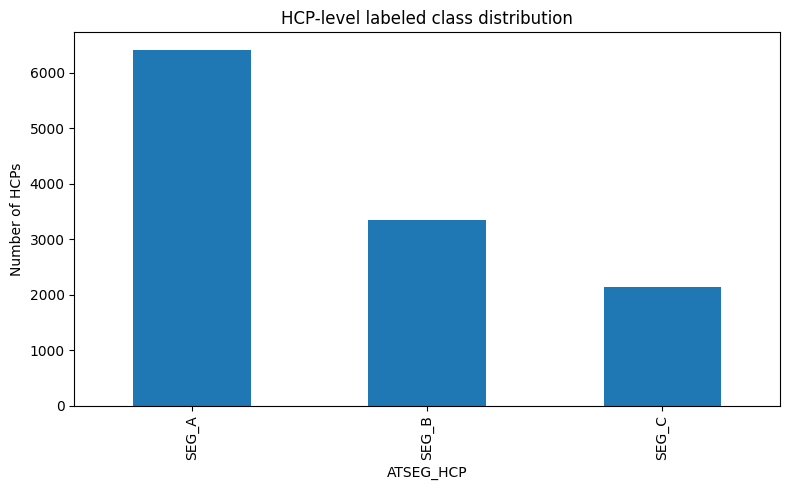

In [5]:
plot_df = label_distribution[label_distribution["ATSEG_HCP"].notna()].copy()

ax = plot_df.plot(
    kind="bar",
    x="ATSEG_HCP",
    y="hcp_count",
    figsize=(8, 5),
    legend=False,
    title="HCP-level labeled class distribution"
)
ax.set_xlabel("ATSEG_HCP")
ax.set_ylabel("Number of HCPs")
plt.tight_layout()
plt.show()


## 3. Structural integrity checks


In [6]:
duplicate_pairs = int(df.duplicated(["NUEVO_ID", "WEEK_ID"]).sum())

rows_per_hcp = df.groupby("NUEVO_ID").size()
weeks_per_hcp = df.groupby("NUEVO_ID")["WEEK_ID"].nunique()
label_consistency = df.groupby("NUEVO_ID")["ATSEG_HCP"].nunique(dropna=True)

integrity = pd.DataFrame([
    {"check": "duplicate_hcp_week_pairs", "value": duplicate_pairs},
    {"check": "rows_per_hcp_min", "value": int(rows_per_hcp.min())},
    {"check": "rows_per_hcp_median", "value": float(rows_per_hcp.median())},
    {"check": "rows_per_hcp_max", "value": int(rows_per_hcp.max())},
    {"check": "weeks_per_hcp_min", "value": int(weeks_per_hcp.min())},
    {"check": "weeks_per_hcp_median", "value": float(weeks_per_hcp.median())},
    {"check": "weeks_per_hcp_max", "value": int(weeks_per_hcp.max())},
    {"check": "max_unique_labels_per_hcp", "value": int(label_consistency.max())},
])

integrity


,check,value
0,duplicate_hcp_week_pairs,0.0000
1,rows_per_hcp_min,86.0000
2,rows_per_hcp_median,86.0000
3,rows_per_hcp_max,86.0000
4,weeks_per_hcp_min,86.0000
5,weeks_per_hcp_median,86.0000
6,weeks_per_hcp_max,86.0000
7,max_unique_labels_per_hcp,1.0000


In [7]:
gap_distribution = (
    pd.to_datetime(df["WEEK_ID"])
    .groupby(df["NUEVO_ID"])
    .diff()
    .dropna()
    .dt.days
    .value_counts()
    .sort_index()
    .rename_axis("day_gap")
    .reset_index(name="count")
)

gap_distribution.head(10)


,day_gap,count
0,7,1779135


## 4. Feature groups for EDA


In [8]:
specialty_dummy_cols = ["SPEC_GE", "SPEC_GPFM", "SPEC_IM", "SPEC_NRP", "SPEC_OTHER_SPEC", "SPEC_PHA"]
state_dummy_cols = ["STATE_1", "STATE_2", "STATE_3", "STATE_4", "STATE_5", "STATE_6", "STATE_7", "STATE_8", "STS_OTHER_STS"]
age_dummy_cols = ["(1940, 1960]", "(1960, 1980]", "(1980, 2000]", "(2000, 2020]", "(2020, 2030]"]
calendar_cols = ["YEAR", "QTR", "YEAR_QTR"]

trx_cols = [c for c in df.columns if c.endswith("_TRX")]
nrx_cols = [c for c in df.columns if c.endswith("_NRX")]
nbrx_cols = [c for c in df.columns if c.endswith("_NBRX")]
claim_cols = [c for c in df.columns if c.startswith("N_CLM")]
marketing_cols = ["RTE", "SAMPLES", "COPAY", "DIRECTMAIL", "SPK", "DETAILS"]
rolling_cols = [c for c in df.columns if "_R" in c and c.endswith("SUM")]
gidx_cols = [c for c in df.columns if c.endswith("_GIDX")]

dynamic_numeric_cols = [
    c for c in (trx_cols + nrx_cols + nbrx_cols + claim_cols + marketing_cols + rolling_cols + gidx_cols)
    if c in df.columns
]

static_dummy_cols = [c for c in (specialty_dummy_cols + state_dummy_cols + age_dummy_cols) if c in df.columns]

core_temporal_cols = [c for c in [
    "UC_TRX", "ORAL_TRX", "IL23_TRX",
    "UC_NRX", "ORAL_NRX", "IL23_NRX",
    "RTE", "SAMPLES", "COPAY", "DIRECTMAIL",
    "UC_TRX_R4_16SUM", "ORAL_NBRX_R4_29SUM", "IL23_NBRX_R4_29SUM"
] if c in df.columns]

print("Dynamic numeric columns:", len(dynamic_numeric_cols))
print("Static dummy columns:", len(static_dummy_cols))
print("Core temporal columns:", core_temporal_cols)


Dynamic numeric columns: 42
Static dummy columns: 20
Core temporal columns: ['UC_TRX', 'ORAL_TRX', 'IL23_TRX', 'UC_NRX', 'ORAL_NRX', 'IL23_NRX', 'RTE', 'SAMPLES', 'COPAY', 'DIRECTMAIL', 'UC_TRX_R4_16SUM', 'ORAL_NBRX_R4_29SUM', 'IL23_NBRX_R4_29SUM']


## 5. Missingness profile

The uploaded dataset has virtually no feature missingness.  
The only systematic missing field is the target, which is missing for unlabeled HCPs.


In [9]:
missing_profile = (
    df.isna().mean()
    .sort_values(ascending=False)
    .rename_axis("column")
    .reset_index(name="missing_rate")
)

missing_profile[missing_profile["missing_rate"] > 0]


,column,missing_rate
0,ATSEG_HCP,0.4315
1,ATSEG_RAW,0.4315
2,ATSEG,0.4315
3,AGE_RANGE_GROUP,0.1780


## 6. Build HCP-level aggregates for analysis

A professional baseline before neural networks should work at HCP level.  
This section builds a compact HCP table using weekly summaries.


In [10]:
agg_mean = df.groupby("NUEVO_ID")[dynamic_numeric_cols].mean().add_suffix("__mean")
agg_std = df.groupby("NUEVO_ID")[dynamic_numeric_cols].std(ddof=0).fillna(0).add_suffix("__std")
agg_last = (
    df.sort_values(["NUEVO_ID", "WEEK_ID"])
    .groupby("NUEVO_ID")[dynamic_numeric_cols]
    .last()
    .add_suffix("__last")
)
agg_first = (
    df.sort_values(["NUEVO_ID", "WEEK_ID"])
    .groupby("NUEVO_ID")[dynamic_numeric_cols]
    .first()
    .add_suffix("__first")
)

hcp_features = pd.concat([agg_mean, agg_std, agg_last, agg_first], axis=1).reset_index()
hcp_features = hcp_features.merge(
    hcp_manifest[["NUEVO_ID", "ATSEG_HCP", "IS_LABELED_HCP", "SPECIALTY_GROUP", "STATE_GROUP", "AGE_RANGE_GROUP", "HCP_FOLD"]],
    on="NUEVO_ID",
    how="left"
)

for col in core_temporal_cols:
    hcp_features[f"{col}__delta_last_minus_first"] = hcp_features[f"{col}__last"] - hcp_features[f"{col}__first"]

print("HCP feature table shape:", hcp_features.shape)
hcp_features.head(3)


HCP feature table shape: (20931, 188)


,NUEVO_ID,UC_TRX__mean,ORAL_TRX__mean,IL23_TRX__mean,BRAND1_TRX__mean,BRAND2_TRX__mean,UC_NRX__mean,ORAL_NRX__mean,IL23_NRX__mean,BRAND1_NRX__mean,BRAND2_NRX__mean,BRAND1_NBRX__mean,BRAND2_NBRX__mean,ORAL_NBRX__mean,IL23_NBRX__mean,N_CLMBRAND3__mean,N_CLMBRAND1__mean,N_CLMBRAND4__mean,N_CLMBRAND2__mean,N_CLMOTHERS__mean,N_CLMBRAND3_NEW__mean,N_CLMBRAND1_NEW__mean,N_CLMBRAND4_NEW__mean,N_CLMBRAND2_NEW__mean,N_CLMOTHERS_NEW__mean,N_CLMBRAND3NEW_TO_BRAND__mean,N_CLMBRAND1_NEW_TO_BRAND__mean,N_CLMBRAND4_NEW_TO_BRAND__mean,N_CLMBRAND2_NEW_TO_BRAND__mean,N_CLMOTHERS_NEW_TO_BRAND__mean,RTE__mean,SAMPLES__mean,COPAY__mean,DIRECTMAIL__mean,SPK__mean,DETAILS__mean,UC_TRX_R4_16SUM__mean,ORAL_NBRX_R4_29SUM__mean,IL23_NBRX_R4_29SUM__mean,BRAND1_NTB_GIDX__mean,BRAND2_NTB_GIDX__mean,BRAND1_T_GIDX__mean,BRAND2_T_GIDX__mean,UC_TRX__std,ORAL_TRX__std,IL23_TRX__std,BRAND1_TRX__std,BRAND2_TRX__std,UC_NRX__std,ORAL_NRX__std,IL23_NRX__std,BRAND1_NRX__std,BRAND2_NRX__std,BRAND1_NBRX__std,BRAND2_NBRX__std,ORAL_NBRX__std,IL23_NBRX__std,N_CLMBRAND3__std,N_CLMBRAND1__std,N_CLMBRAND4__std,N_CLMBRAND2__std,N_CLMOTHERS__std,N_CLMBRAND3_NEW__std,N_CLMBRAND1_NEW__std,N_CLMBRAND4_NEW__std,N_CLMBRAND2_NEW__std,N_CLMOTHERS_NEW__std,N_CLMBRAND3NEW_TO_BRAND__std,N_CLMBRAND1_NEW_TO_BRAND__std,N_CLMBRAND4_NEW_TO_BRAND__std,N_CLMBRAND2_NEW_TO_BRAND__std,N_CLMOTHERS_NEW_TO_BRAND__std,RTE__std,SAMPLES__std,COPAY__std,DIRECTMAIL__std,SPK__std,DETAILS__std,UC_TRX_R4_16SUM__std,ORAL_NBRX_R4_29SUM__std,IL23_NBRX_R4_29SUM__std,BRAND1_NTB_GIDX__std,BRAND2_NTB_GIDX__std,BRAND1_T_GIDX__std,BRAND2_T_GIDX__std,UC_TRX__last,ORAL_TRX__last,IL23_TRX__last,BRAND1_TRX__last,BRAND2_TRX__last,UC_NRX__last,ORAL_NRX__last,IL23_NRX__last,BRAND1_NRX__last,BRAND2_NRX__last,BRAND1_NBRX__last,BRAND2_NBRX__last,ORAL_NBRX__last,IL23_NBRX__last,N_CLMBRAND3__last,N_CLMBRAND1__last,N_CLMBRAND4__last,N_CLMBRAND2__last,N_CLMOTHERS__last,N_CLMBRAND3_NEW__last,N_CLMBRAND1_NEW__last,N_CLMBRAND4_NEW__last,N_CLMBRAND2_NEW__last,N_CLMOTHERS_NEW__last,N_CLMBRAND3NEW_TO_BRAND__last,N_CLMBRAND1_NEW_TO_BRAND__last,N_CLMBRAND4_NEW_TO_BRAND__last,N_CLMBRAND2_NEW_TO_BRAND__last,N_CLMOTHERS_NEW_TO_BRAND__last,RTE__last,SAMPLES__last,COPAY__last,DIRECTMAIL__last,SPK__last,DETAILS__last,UC_TRX_R4_16SUM__last,ORAL_NBRX_R4_29SUM__last,IL23_NBRX_R4_29SUM__last,BRAND1_NTB_GIDX__last,BRAND2_NTB_GIDX__last,BRAND1_T_GIDX__last,BRAND2_T_GIDX__last,UC_TRX__first,ORAL_TRX__first,IL23_TRX__first,BRAND1_TRX__first,BRAND2_TRX__first,UC_NRX__first,ORAL_NRX__first,IL23_NRX__first,BRAND1_NRX__first,BRAND2_NRX__first,BRAND1_NBRX__first,BRAND2_NBRX__first,ORAL_NBRX__first,IL23_NBRX__first,N_CLMBRAND3__first,N_CLMBRAND1__first,N_CLMBRAND4__first,N_CLMBRAND2__first,N_CLMOTHERS__first,N_CLMBRAND3_NEW__first,N_CLMBRAND1_NEW__first,N_CLMBRAND4_NEW__first,N_CLMBRAND2_NEW__first,N_CLMOTHERS_NEW__first,N_CLMBRAND3NEW_TO_BRAND__first,N_CLMBRAND1_NEW_TO_BRAND__first,N_CLMBRAND4_NEW_TO_BRAND__first,N_CLMBRAND2_NEW_TO_BRAND__first,N_CLMOTHERS_NEW_TO_BRAND__first,RTE__first,SAMPLES__first,COPAY__first,DIRECTMAIL__first,SPK__first,DETAILS__first,UC_TRX_R4_16SUM__first,ORAL_NBRX_R4_29SUM__first,IL23_NBRX_R4_29SUM__first,BRAND1_NTB_GIDX__first,BRAND2_NTB_GIDX__first,BRAND1_T_GIDX__first,BRAND2_T_GIDX__first,ATSEG_HCP,IS_LABELED_HCP,SPECIALTY_GROUP,STATE_GROUP,AGE_RANGE_GROUP,HCP_FOLD,UC_TRX__delta_last_minus_first,ORAL_TRX__delta_last_minus_first,IL23_TRX__delta_last_minus_first,UC_NRX__delta_last_minus_first,ORAL_NRX__delta_last_minus_first,IL23_NRX__delta_last_minus_first,RTE__delta_last_minus_first,SAMPLES__delta_last_minus_first,COPAY__delta_last_minus_first,DIRECTMAIL__delta_last_minus_first,UC_TRX_R4_16SUM__delta_last_minus_first,ORAL_NBRX_R4_29SUM__delta_last_minus_first,IL23_NBRX_R4_29SUM__delta_last_minus_first
0,1,0.0118,0.0000,0.0000,0.0000,0.0000,0.0060,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0279,0.0000,0.0000,0.0000,0.0000,0.0047,0.0000,0.0000,0.0000,0.0000,0.0047,0.0000,0.0000,0.0000,0.0

## 7. Labeled vs unlabeled cohort drift at HCP level

This section compares the labeled and unlabeled populations using HCP-level aggregated features.


In [11]:
def compute_psi(expected, actual, bins=10):
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna()
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna()

    if expected.nunique() < 2 or actual.nunique() < 2:
        return np.nan

    quantiles = np.linspace(0, 1, bins + 1)
    breakpoints = np.unique(np.quantile(expected, quantiles))
    if len(breakpoints) < 3:
        return np.nan

    expected_bins = pd.cut(expected, bins=breakpoints, include_lowest=True)
    actual_bins = pd.cut(actual, bins=breakpoints, include_lowest=True)

    expected_dist = expected_bins.value_counts(normalize=True, sort=False).replace(0, 1e-6)
    actual_dist = actual_bins.value_counts(normalize=True, sort=False).replace(0, 1e-6)

    return float(((actual_dist - expected_dist) * np.log(actual_dist / expected_dist)).sum())

drift_feature_cols = [c for c in hcp_features.columns if c.endswith("__mean") or c.endswith("__std") or c.endswith("__last")]

labeled_hcp = hcp_features[hcp_features["IS_LABELED_HCP"] == 1]
unlabeled_hcp = hcp_features[hcp_features["IS_LABELED_HCP"] == 0]

drift_rows = []
for col in drift_feature_cols:
    x1 = labeled_hcp[col]
    x2 = unlabeled_hcp[col]
    ks_stat, ks_p = ks_2samp(x1, x2)
    psi_value = compute_psi(x1, x2, bins=10)

    drift_rows.append({
        "feature": col,
        "labeled_mean": float(x1.mean()),
        "unlabeled_mean": float(x2.mean()),
        "mean_diff": float(x2.mean() - x1.mean()),
        "ks_stat": float(ks_stat),
        "ks_pvalue": float(ks_p),
        "psi": psi_value,
    })

drift_df = pd.DataFrame(drift_rows).sort_values(["psi", "ks_stat"], ascending=[False, False])
drift_df.head(20)


,feature,labeled_mean,unlabeled_mean,mean_diff,ks_stat,ks_pvalue,psi
18,N_CLMOTHERS__mean,0.6586,0.1494,-0.5092,0.5464,0.0000,1.7224
0,UC_TRX__mean,0.3660,0.0832,-0.2827,0.5432,0.0000,1.7142
35,UC_TRX_R4_16SUM__mean,4.4485,1.1119,-3.3366,0.5401,0.0000,1.6662
60,N_CLMOTHERS__std,0.4587,0.1711,-0.2875,0.5363,0.0000,1.6289
42,UC_TRX__std,0.2517,0.0980,-0.1537,0.5190,0.0000,1.5301
5,UC_NRX__mean,0.1612,0.0430,-0.1181,0.5021,0.0000,1.4454
23,N_CLMOTHERS_NEW__mean,0.1376,0.0348,-0.1027,0.5044,0.0000,1.4217
65,N_CLMOTHERS_NEW__std,0.1956,0.0747,-0.1209,0.5031,0.0000,1.3842
47,UC_NRX__std,0.2125,0.0887,-0.1237,0.4814,0.0000,1.2955
28,N_CLMOTHERS_NEW_TO_BRAND__mean,0.0528,0.0152,-0.0376,0.4857,0.0000,1.2665


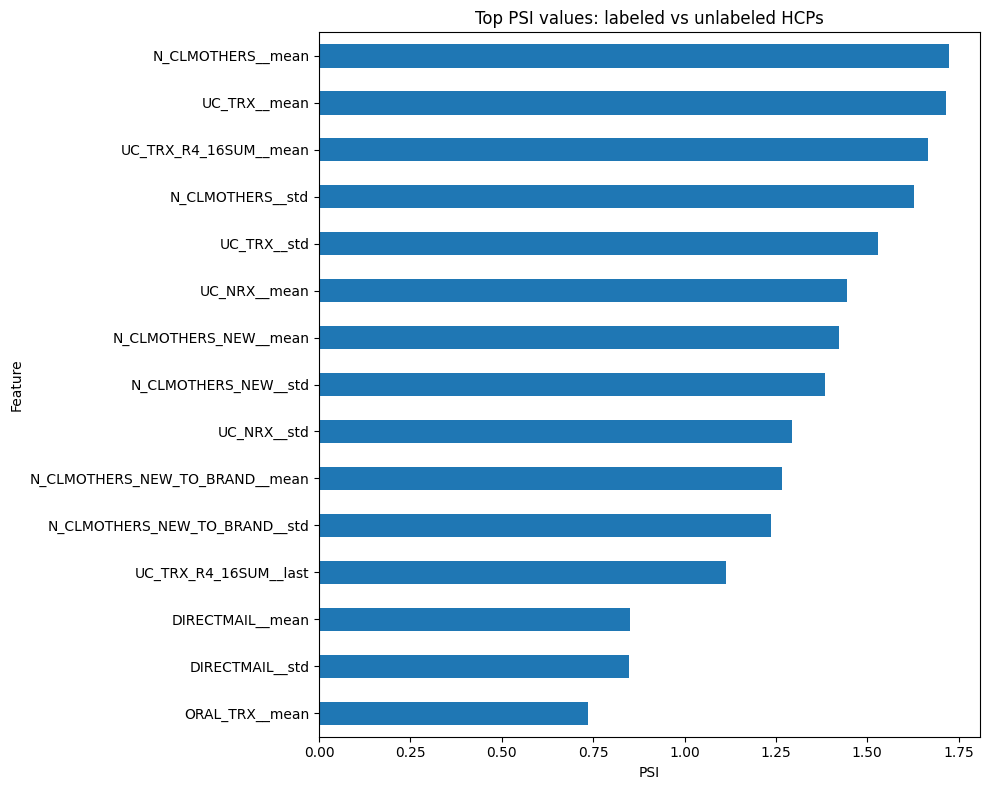

In [12]:
top_drift = drift_df.dropna(subset=["psi"]).head(15).sort_values("psi")
ax = top_drift.plot(kind="barh", x="feature", y="psi", figsize=(10, 8), legend=False, title="Top PSI values: labeled vs unlabeled HCPs")
ax.set_xlabel("PSI")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


## 8. Class-level descriptive statistics within labeled HCPs


In [13]:
selected_summary_cols = [c for c in [
    "UC_TRX__mean", "ORAL_TRX__mean", "IL23_TRX__mean",
    "UC_NRX__mean", "ORAL_NRX__mean", "IL23_NRX__mean",
    "RTE__mean", "SAMPLES__mean", "COPAY__mean", "DIRECTMAIL__mean",
    "UC_TRX_R4_16SUM__last", "ORAL_NBRX_R4_29SUM__last", "IL23_NBRX_R4_29SUM__last"
] if c in hcp_features.columns]

class_summary = (
    labeled_hcp.groupby("ATSEG_HCP")[selected_summary_cols]
    .median()
    .T
)

class_summary


ATSEG_HCP,SEG_A,SEG_B,SEG_C
UC_TRX__mean,0.1198,0.3504,0.3842
ORAL_TRX__mean,0.0064,0.0809,0.0583
IL23_TRX__mean,0.0000,0.0239,0.0333
UC_NRX__mean,0.0514,0.1463,0.1597
ORAL_NRX__mean,0.0032,0.0356,0.0260
IL23_NRX__mean,0.0000,0.0110,0.0179
RTE__mean,0.0000,0.0000,0.0000
SAMPLES__mean,0.0000,0.0000,0.0000
COPAY__mean,0.0000,0.0000,0.0000
DIRECTMAIL__mean,0.0209,0.0523,0.0628


## 9. Temporal signal inspection

The goal here is not to train a sequence model yet, but to verify whether the 86-week histories carry meaningful temporal structure.


In [14]:
if core_temporal_cols:
    temporal_class_profile = (
        df[df["IS_LABELED_HCP"] == 1]
        .groupby(["ATSEG_HCP", "WEEK_IDX"])[core_temporal_cols]
        .mean()
        .reset_index()
    )
    temporal_class_profile.head()
else:
    temporal_class_profile = pd.DataFrame()
    print("No core temporal columns were found.")


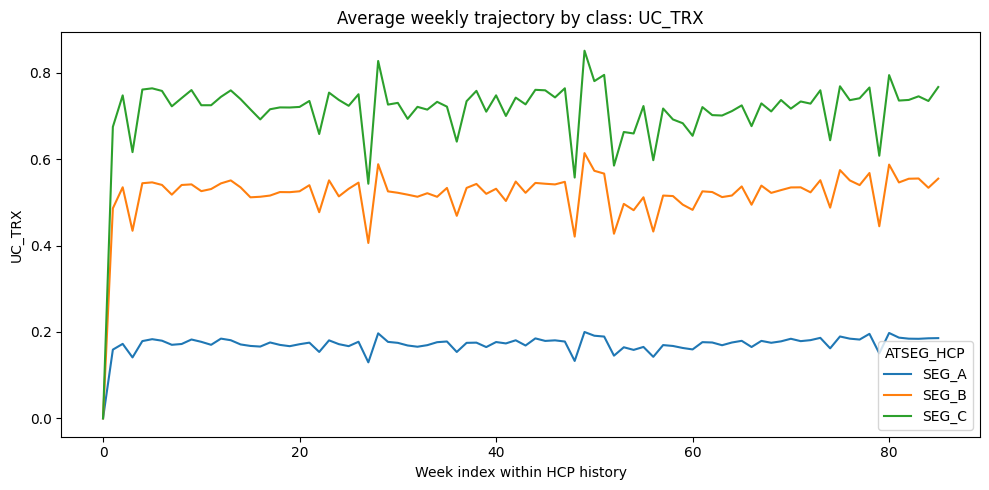

In [15]:
if not temporal_class_profile.empty:
    feature_to_plot = core_temporal_cols[0]

    fig, ax = plt.subplots(figsize=(10, 5))
    for target_value, grp in temporal_class_profile.groupby("ATSEG_HCP"):
        ax.plot(grp["WEEK_IDX"], grp[feature_to_plot], label=target_value)

    ax.set_title(f"Average weekly trajectory by class: {feature_to_plot}")
    ax.set_xlabel("Week index within HCP history")
    ax.set_ylabel(feature_to_plot)
    ax.legend(title="ATSEG_HCP")
    plt.tight_layout()
    plt.show()


In [16]:
lag_results = []
for col in core_temporal_cols:
    sampled = (
        df[df["IS_LABELED_HCP"] == 1]
        .groupby("NUEVO_ID")[col]
        .apply(lambda s: s.astype(float).autocorr(lag=1))
        .dropna()
    )
    lag_results.append({
        "feature": col,
        "mean_lag1_autocorr": float(sampled.mean()) if len(sampled) else np.nan,
        "median_lag1_autocorr": float(sampled.median()) if len(sampled) else np.nan,
    })

autocorr_df = pd.DataFrame(lag_results).sort_values("mean_lag1_autocorr", ascending=False)
autocorr_df


,feature,mean_lag1_autocorr,median_lag1_autocorr
12,IL23_NBRX_R4_29SUM,0.9498,0.9593
10,UC_TRX_R4_16SUM,0.9490,0.9629
11,ORAL_NBRX_R4_29SUM,0.9433,0.9479
8,COPAY,0.0337,-0.0216
5,IL23_NRX,0.0076,-0.0217
2,IL23_TRX,0.0056,-0.0242
6,RTE,-0.0018,-0.0216
3,UC_NRX,-0.0047,-0.0241
4,ORAL_NRX,-0.0147,-0.0273
7,SAMPLES,-0.0181,-0.0119


## 10. Distribution shape and outlier concentration at HCP level


In [17]:
shape_rows = []
for col in [c for c in hcp_features.columns if c.endswith("__mean")]:
    series = hcp_features[col].replace([np.inf, -np.inf], np.nan).dropna()
    if len(series) == 0:
        continue

    p50 = series.quantile(0.50)
    p95 = series.quantile(0.95)
    p99 = series.quantile(0.99)

    shape_rows.append({
        "feature": col,
        "skewness": float(skew(series)),
        "p95": float(p95),
        "p99": float(p99),
        "p99_to_p50_ratio": float(p99 / p50) if p50 not in [0, np.nan] else np.nan,
    })

shape_df = pd.DataFrame(shape_rows).sort_values("skewness", ascending=False)
shape_df.head(20)


,feature,skewness,p95,p99,p99_to_p50_ratio
7,IL23_NRX__mean,65.7509,0.0607,0.2085,NaN
2,IL23_TRX__mean,37.6776,0.1181,0.3897,NaN
13,IL23_NBRX__mean,36.9276,0.0733,0.2035,NaN
37,IL23_NBRX_R4_29SUM__mean,33.8377,1.5953,4.2244,32.4375
20,N_CLMBRAND1_NEW__mean,15.7418,0.0000,0.0047,NaN
19,N_CLMBRAND3_NEW__mean,12.7647,0.0744,0.2605,NaN
14,N_CLMBRAND3__mean,12.0960,0.3535,0.9814,211.0000
31,COPAY__mean,11.9745,0.0000,0.0930,NaN
3,BRAND1_TRX__mean,11.8866,0.0022,0.0209,NaN
8,BRAND1_NRX__mean,11.6807,0.0032,0.0099,NaN


## 11. UMAP overlap view for labeled HCPs

This is a compact visual diagnostic of class separability using HCP-level aggregated features.
It is not a modeling step.


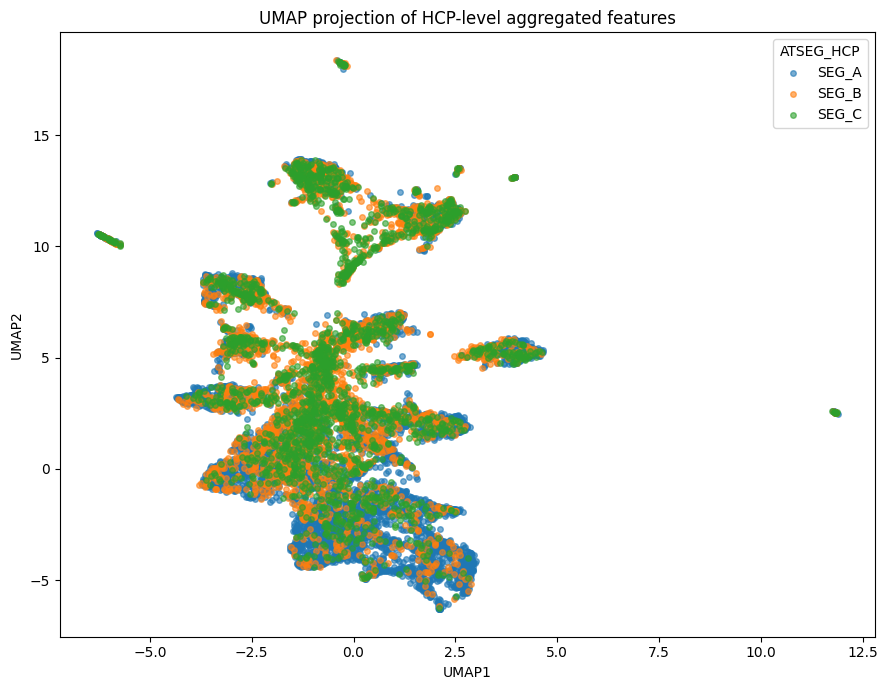

In [18]:
umap_input_cols = [c for c in hcp_features.columns if c.endswith("__mean") or c.endswith("__std") or c.endswith("__last")]
umap_df = labeled_hcp[["NUEVO_ID", "ATSEG_HCP"] + umap_input_cols].dropna()

X = umap_df[umap_input_cols].values
X_scaled = StandardScaler().fit_transform(X)

try:
    from umap import UMAP
except ImportError as e:
    raise ImportError(
        "UMAP requires the package 'umap-learn'. Install it before running this section with: pip install umap-learn"
    ) from e

umap_model = UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.15,
    metric="euclidean",
    random_state=42
)
coords = umap_model.fit_transform(X_scaled)

umap_plot_df = pd.DataFrame({
    "UMAP1": coords[:, 0],
    "UMAP2": coords[:, 1],
    "ATSEG_HCP": umap_df["ATSEG_HCP"].values
})

fig, ax = plt.subplots(figsize=(9, 7))
for label, grp in umap_plot_df.groupby("ATSEG_HCP"):
    ax.scatter(grp["UMAP1"], grp["UMAP2"], s=16, alpha=0.6, label=label)

ax.set_title("UMAP projection of HCP-level aggregated features")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.legend(title="ATSEG_HCP")
plt.tight_layout()
plt.show()

## 12. EDA conclusions for the next notebook

The evidence in this notebook should be used to define the modeling roadmap:

1. the correct prediction unit is the HCP, not the individual week
2. class imbalance must be evaluated at HCP level
3. labeled and unlabeled HCPs should be compared before any pseudo-labeling
4. a strong tabular baseline should be built first using HCP-level aggregates
5. threshold tuning and calibration should be treated as first-class components of the baseline
6. neural sequence models should only be considered after the HCP-level baseline is stable and difficult to beat


In [20]:
final_checks = {
    "n_hcp_features_rows": int(hcp_features.shape[0]),
    "n_hcp_features_cols": int(hcp_features.shape[1]),
    "n_labeled_hcp_features_rows": int(labeled_hcp.shape[0]),
    "n_unlabeled_hcp_features_rows": int(unlabeled_hcp.shape[0]),
    "top_5_drift_features": drift_df["feature"].head(5).tolist(),
    "top_5_skewed_hcp_features": shape_df["feature"].head(5).tolist(),
}

final_checks


{'n_hcp_features_rows': 20931,
 'n_hcp_features_cols': 188,
 'n_labeled_hcp_features_rows': 11899,
 'n_unlabeled_hcp_features_rows': 9032,
 'top_5_drift_features': ['N_CLMOTHERS__mean',
  'UC_TRX__mean',
  'UC_TRX_R4_16SUM__mean',
  'N_CLMOTHERS__std',
  'UC_TRX__std'],
 'top_5_skewed_hcp_features': ['IL23_NRX__mean',
  'IL23_TRX__mean',
  'IL23_NBRX__mean',
  'IL23_NBRX_R4_29SUM__mean',
  'N_CLMBRAND1_NEW__mean']}